In [2]:
from config import DATA_PROCESSED
import os
print(os.listdir(DATA_PROCESSED)[:5])  # show first 5 files

['aps-2022-author-doi-citation-affil.mat', 'aps-2022-doi-citation.mat', 'aps-2020-author-doi-citation.mat', 'aps-dataset-citations-2022.csv']


In [1]:
import os
from config import DATA_PROCESSED, DATA_SAMPLE

print("Processed data files:", os.listdir(DATA_PROCESSED))
print("Sample data files:", os.listdir(DATA_SAMPLE))

Processed data files: ['aps-2022-author-doi-citation-affil.mat', 'aps-2022-doi-citation.mat', 'aps-2020-author-doi-citation.mat', 'aps-dataset-citations-2022.csv']
Sample data files: ['sample_citation_data.mat', 'ba_n3000_k20.mat']


In [5]:
import h5py
from config import DATA_SAMPLE

file_path = DATA_SAMPLE + "/sample_citation_data.mat"
with h5py.File(file_path, 'r') as f:
    print("Top-level keys:", list(f.keys()))
    
    for k in f.keys():
        item = f[k]
        print(f"Key: {k}")
        if isinstance(item, h5py.Group):
            print("  Type: Group")
            print("  Contains:", list(item.keys()))
        elif isinstance(item, h5py.Dataset):
            print("  Type: Dataset")
            print("  Shape:", item.shape)
            print("  Dtype:", item.dtype)

Top-level keys: ['#refs#', '#subsystem#', 'C', 'doi']
Key: #refs#
  Type: Group
  Contains: ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j']
Key: #subsystem#
  Type: Group
  Contains: ['MCOS']
Key: C
  Type: Group
  Contains: ['data', 'ir', 'jc']
Key: doi
  Type: Dataset
  Shape: (1, 6)
  Dtype: uint32


In [6]:
import h5py
from scipy.sparse import csc_matrix
import numpy as np
from config import DATA_SAMPLE

file_path = DATA_SAMPLE + "/sample_citation_data.mat"
with h5py.File(file_path, 'r') as f:
    C_group = f['C']
    data = C_group['data'][:].flatten()
    ir = C_group['ir'][:].flatten()
    jc = C_group['jc'][:].flatten()

    # reconstruct sparse CSC matrix
    n_cols = len(jc) - 1
    n_rows = ir.max() + 1  # 0-indexed
    C_sparse = csc_matrix((data, ir, jc), shape=(n_rows, n_cols))

print("C_sparse shape:", C_sparse.shape)
print("Number of nonzeros:", C_sparse.nnz)

C_sparse shape: (1041, 1041)
Number of nonzeros: 999


In [7]:
from scipy.sparse import csc_matrix
degrees = np.array(C_sparse.sum(axis=0)).flatten()  # total outgoing citations per node
print("Top 5 degrees:", np.sort(degrees)[-5:])

Top 5 degrees: [24. 27. 32. 55. 92.]


Top 5 node degrees: [24. 27. 32. 55. 92.]
Gini coefficient of node degrees: 0.8294
Top 20% nodes account for 82.78% of total citations


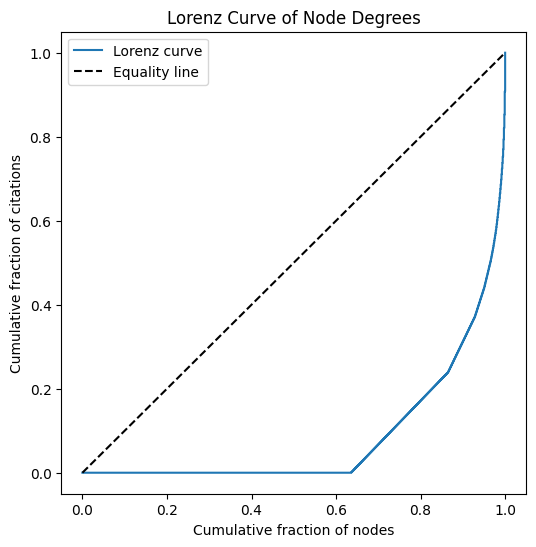

In [9]:
# python/experiments/rediscover_sample.py
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import csc_matrix
from config import DATA_SAMPLE

# 1️⃣ Load sparse matrix C from MATLAB v7.3 file
file_path = DATA_SAMPLE + "/sample_citation_data.mat"
with h5py.File(file_path, 'r') as f:
    C_group = f['C']
    data = C_group['data'][:].flatten()
    ir = C_group['ir'][:].flatten()
    jc = C_group['jc'][:].flatten()
    n_cols = len(jc) - 1
    n_rows = ir.max() + 1
    C_sparse = csc_matrix((data, ir, jc), shape=(n_rows, n_cols))

# 2️⃣ Compute node degrees (outgoing citations)
degrees = np.array(C_sparse.sum(axis=0)).flatten()
print("Top 5 node degrees:", np.sort(degrees)[-5:])

# 3️⃣ Gini coefficient
def gini(x):
    x = np.sort(np.asarray(x).flatten())
    if np.all(x == 0): return 0.0
    n = len(x)
    return (2*np.sum((np.arange(1,n+1)*x)))/(n*np.sum(x)) - (n+1)/n

gini_deg = gini(degrees)
print(f"Gini coefficient of node degrees: {gini_deg:.4f}")

# 4️⃣ Pareto top 20% share
def pareto_share(x, p=0.2):
    x = np.sort(np.asarray(x))[::-1]
    k = max(1, int(len(x)*p))
    return x[:k].sum() / x.sum()

pareto20 = pareto_share(degrees)
print(f"Top 20% nodes account for {pareto20*100:.2f}% of total citations")

# 5️⃣ Lorenz curve
def lorenz_curve(x):
    x = np.sort(np.asarray(x))
    cum = np.cumsum(x)
    return np.insert(cum / cum[-1], 0, 0)

lorenz = lorenz_curve(degrees)
plt.figure(figsize=(6,6))
plt.plot(np.linspace(0,1,len(lorenz)), lorenz, drawstyle='steps-post', label='Lorenz curve')
plt.plot([0,1],[0,1],'k--', label='Equality line')
plt.xlabel('Cumulative fraction of nodes')
plt.ylabel('Cumulative fraction of citations')
plt.title('Lorenz Curve of Node Degrees')
plt.legend()
plt.show()